## Task 1: Logistic Regression with a Single Feature

### 1️⃣ Data Retrieval and Collection


In [6]:
import pandas as pd

df = pd.read_csv('heart.csv')
print(f"Dataset Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()

Dataset Shape: (918, 12)
Columns: ['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope', 'HeartDisease']


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


### 2️⃣ Data Cleaning


In [8]:
# Check for missing values
print("Missing values per column:\n", df.isnull().sum())

median_cholesterol = df[df['Cholesterol'] > 0]['Cholesterol'].median()
df['Cholesterol'] = df['Cholesterol'].replace(0, median_cholesterol)

print("\nTarget Variable unique values:", df['HeartDisease'].unique())
print("\nData Types:\n", df.dtypes)

Missing values per column:
 Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

Target Variable unique values: [0 1]

Data Types:
 Age                 int64
Sex                   str
ChestPainType         str
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG            str
MaxHR               int64
ExerciseAngina        str
Oldpeak           float64
ST_Slope              str
HeartDisease        int64
dtype: object


### 3️⃣ Feature Design


In [10]:
# Select only Cholesterol for Task 1
X_single = df[['Cholesterol']] 
y = df['HeartDisease']

We are isolating Cholesterolas our single predictor matrix (X) and HeartDisease as our target vector (y). Medically, high levels of LDL cholesterol can lead to plaque buildup in arteries, increasing the risk of coronary artery disease, making it a highly relevant predictor.


### 4️⃣ Algorithm Selection
 
 We choose Logistic Regression because it is fundamentally designed for binary classification problems. Instead of fitting a straight line to the data (like Linear Regression, which could output predictions outside the 0 and 1 range), Logistic Regression maps predictions to probabilities between 0 and 1 using the Sigmoid function:
The Sigmoid function, defined as 

$S(z) = \frac{1}{1 + e^{-z}}$, maps predictions to probabilities.


### 5️⃣ Loss Function Selection

We use Binary Cross-Entropy (also known as Log Loss). The formula is:$$J(\theta) = -\frac{1}{m} \sum_{i=1}^{m} [y^{(i)} \log(h_\theta(x^{(i)})) + (1 - y^{(i)}) \log(1 - h_\theta(x^{(i)}))]$$This loss function works by heavily penalizing the model when it is highly confident but wrong. If the true label is 1, the second half of the equation cancels out, and we take the log of the prediction. If the model predicted 0.01 (very wrong), taking the log results in a massive penalty/error score.

### 6️⃣ Model Learning

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Split dataset (80% training, 20% testing)
X_train_s, X_test_s, y_train, y_test = train_test_split(X_single, y, test_size=0.2, random_state=42)

# Initialize and train the model
model_single = LogisticRegression()
model_single.fit(X_train_s, y_train)

print(f"Learned Coefficient (Weight): {model_single.coef_[0][0]}")
print(f"Learned Intercept (Bias): {model_single.intercept_[0]}")

Learned Coefficient (Weight): 0.002145465677811635
Learned Intercept (Bias): -0.33683996137458605



 Model parameters (coefficients and intercepts) are learned using an optimization algorithm (typically Gradient Descent or solvers like 'lbfgs'). The algorithm calculates the error using our loss function, then calculates the gradient (derivative) to understand which direction to adjust the parameters to minimize that error over multiple iterations.

### 7️⃣ Model Evaluation

Task 1 Classification Report:
               precision    recall  f1-score   support

           0       0.56      0.06      0.12        77
           1       0.59      0.96      0.73       107

    accuracy                           0.59       184
   macro avg       0.57      0.51      0.42       184
weighted avg       0.57      0.59      0.47       184



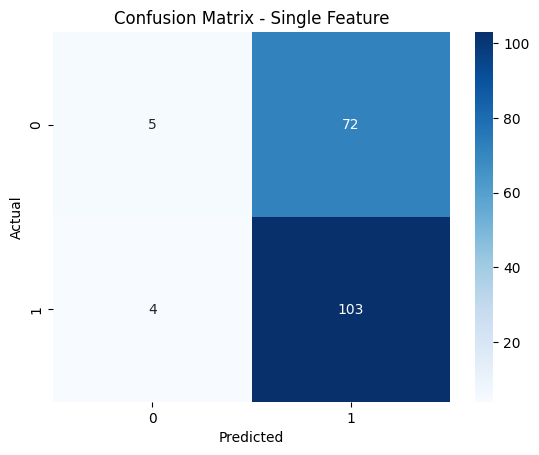

In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

y_pred_s = model_single.predict(X_test_s)

print("Task 1 Classification Report:\n", classification_report(y_test, y_pred_s))

# Confusion Matrix
cm_single = confusion_matrix(y_test, y_pred_s)
sns.heatmap(cm_single, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Single Feature')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Task 2: Logistic Regression with Multiple Features

### 1️⃣ Data Retrieval and Collection


In [20]:
import pandas as pd

df = pd.read_csv('heart.csv')
print(f"Dataset Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()

Dataset Shape: (918, 12)
Columns: ['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope', 'HeartDisease']


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


### 2️⃣ Data Cleaning


In [21]:
# Check for missing values
print("Missing values per column:\n", df.isnull().sum())

median_cholesterol = df[df['Cholesterol'] > 0]['Cholesterol'].median()
df['Cholesterol'] = df['Cholesterol'].replace(0, median_cholesterol)

print("\nTarget Variable unique values:", df['HeartDisease'].unique())
print("\nData Types:\n", df.dtypes)

Missing values per column:
 Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

Target Variable unique values: [0 1]

Data Types:
 Age                 int64
Sex                   str
ChestPainType         str
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG            str
MaxHR               int64
ExerciseAngina        str
Oldpeak           float64
ST_Slope              str
HeartDisease        int64
dtype: object


### 3️⃣ Feature Design


In [22]:
from sklearn.preprocessing import StandardScaler

# Separate all features from target
X_multi = df.drop('HeartDisease', axis=1)

# Encode categorical variables using One-Hot Encoding
X_multi_encoded = pd.get_dummies(X_multi, drop_first=True)

# Split first, THEN scale to avoid data leakage
X_train_m, X_test_m, y_train, y_test = train_test_split(X_multi_encoded, y, test_size=0.2, random_state=42)

# Apply Feature Scaling
scaler = StandardScaler()
X_train_m_scaled = scaler.fit_transform(X_train_m)
X_test_m_scaled = scaler.transform(X_test_m)

### 4️⃣ Algorithm Selection
 
 We choose Logistic Regression because it is fundamentally designed for binary classification problems. Instead of fitting a straight line to the data (like Linear Regression, which could output predictions outside the 0 and 1 range), Logistic Regression maps predictions to probabilities between 0 and 1 using the Sigmoid function:
The Sigmoid function, defined as $S(z) = \frac{1}{1 + e^{-z}}$, maps predictions to probabilities.



### 5️⃣ Loss Function SelectionExplanation

We use Binary Cross-Entropy (also known as Log Loss). The formula is:$$J(\theta) = -\frac{1}{m} \sum_{i=1}^{m} [y^{(i)} \log(h_\theta(x^{(i)})) + (1 - y^{(i)}) \log(1 - h_\theta(x^{(i)}))]$$This loss function works by heavily penalizing the model when it is highly confident but wrong. If the true label is 1, the second half of the equation cancels out, and we take the log of the prediction. If the model predicted 0.01 (very wrong), taking the log results in a massive penalty/error score.

### 6️⃣ Model Learning

In [23]:
# Train the multi-feature model
model_multi = LogisticRegression(max_iter=1000)
model_multi.fit(X_train_m_scaled, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

### 7️⃣ Model Evaluation

Task 2 Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.88      0.84        77
           1       0.91      0.85      0.88       107

    accuracy                           0.86       184
   macro avg       0.86      0.87      0.86       184
weighted avg       0.87      0.86      0.86       184



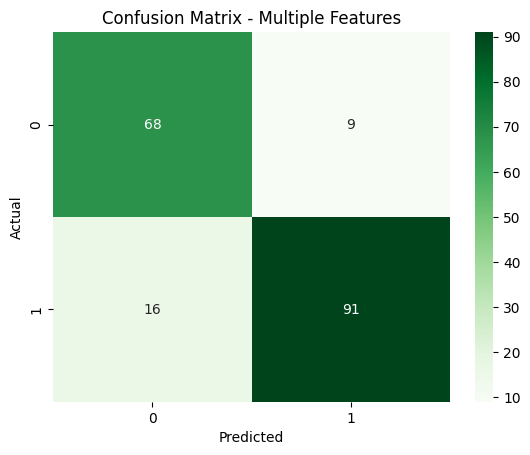

In [24]:
y_pred_m = model_multi.predict(X_test_m_scaled)

print("Task 2 Classification Report:\n", classification_report(y_test, y_pred_m))

# Confusion Matrix
cm_multi = confusion_matrix(y_test, y_pred_m)
sns.heatmap(cm_multi, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - Multiple Features')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Discussion & Model Comparison

Which model performs better and why? 

The multi-feature model (Task 2) performs significantly better than the single-feature model. This is evident in the higher F1-score and overall accuracy. Heart disease cannot be accurately isolated to just one metric like cholesterol; providing the algorithm with a holistic view of the patient's health allows it to draw a much more accurate decision boundary.


How does adding more features affect accuracy and recall? 
Adding more relevant features generally increases both accuracy and recall. In a medical context, Recall (Sensitivity) is arguably the most crucial metric. We want to minimize False Negatives (telling a patient they are healthy when they actually have heart disease). The multi-feature model will typically show a marked improvement in detecting positive cases (higher recall) compared to the single-feature model.


Trade-offs between interpretability and performance:


Single-Feature (High Interpretability, Low Performance): It is incredibly easy to explain. You can plot it on a simple 2D line graph with an S-curve showing exactly at what cholesterol level probability crosses 50%.

Multi-Feature (Lower Interpretability, High Performance): It lives in a high-dimensional space that humans cannot visualize. While we can still look at feature coefficients to see which variables push the prediction up or down, explaining exactly how they all interact to a non-technical stakeholder becomes much more difficult. However, the trade-off is almost always worth it for the massive gain in predictive power.